In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

In [3]:
df= pd.read_csv("iris.csv")
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
#Determinar el numero de renglones de la base de datos
index= df.index
renglones= len(index)
renglones

150

In [8]:
#Estandarización
X = df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]
y = df['variety']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

In [10]:
for i, ratio in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)
PC3: 0.0367 (3.67%)
PC4: 0.0052 (0.52%)


In [11]:
print(f"\nVarianza acumulada primeros 2 componentes: {cumulative_variance[1]:.4f} ({cumulative_variance[1]*100:.2f}%)")
print(f"Varianza acumulada primeros 3 componentes: {cumulative_variance[2]:.4f} ({cumulative_variance[2]*100:.2f}%)")


Varianza acumulada primeros 2 componentes: 0.9581 (95.81%)
Varianza acumulada primeros 3 componentes: 0.9948 (99.48%)


In [12]:
# Crear DataFrame con resultados PCA
pca_df = pd.DataFrame(
    data=X_pca[:, :2],
    columns=['PC1', 'PC2']
)
pca_df['variedad'] = y

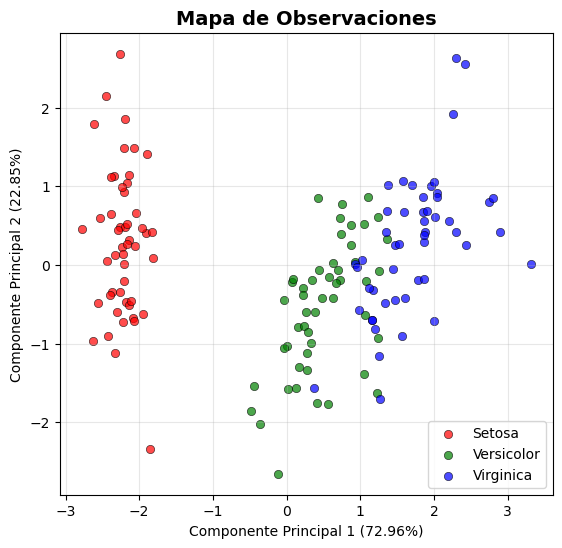

In [13]:
# Gráfico 1: Mapa de observaciones
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colores = {'Setosa': 'red', 'Versicolor': 'green', 'Virginica': 'blue'}
for variedad, color in colores.items():
    mask = pca_df['variedad'] == variedad
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], 
                c=color, label=variedad, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.title('Mapa de Observaciones', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

In [16]:
#Matriz de cargas
cargas_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=caracteristicas
)
print(cargas_df.round(4))

                 PC1     PC2     PC3     PC4
sepal.length  0.5211  0.3774  0.7196 -0.2613
sepal.width  -0.2693  0.9233 -0.2444  0.1235
petal.length  0.5804  0.0245 -0.1421  0.8014
petal.width   0.5649  0.0669 -0.6343 -0.5236


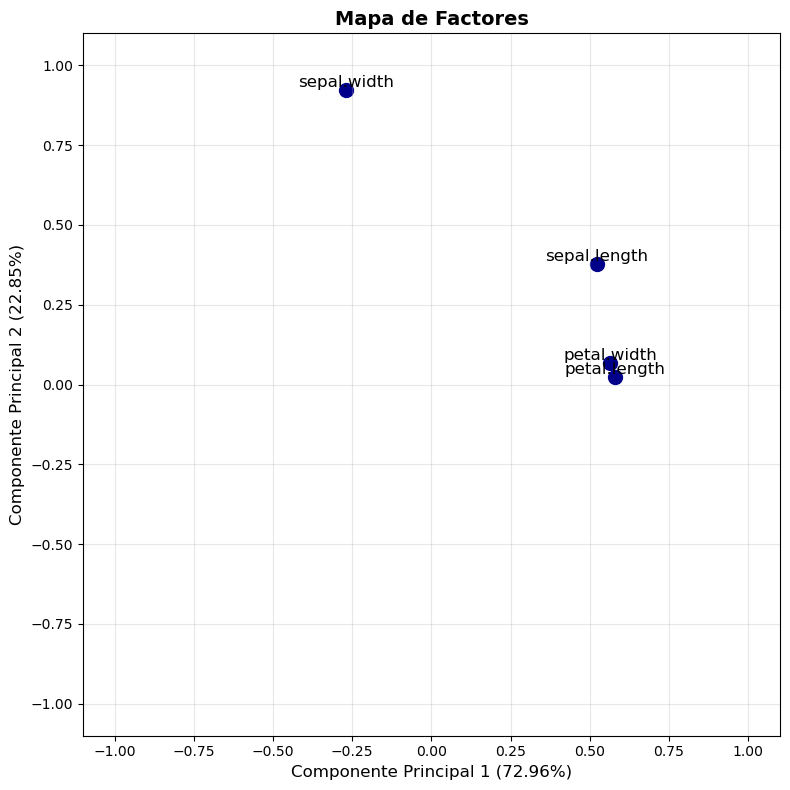

In [20]:
# Crear DataFrame con las cargas (componentes)
cargas_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
)

# Tomar solo las primeras dos componentes para el mapa de factores
x = cargas_df.iloc[:, 0]  # PC1
y = cargas_df.iloc[:, 1]  # PC2
z = cargas_df.index       # Nombres de las variables

# Convertir a numpy arrays
x = x.to_numpy()
y = y.to_numpy()

# Graficar
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Mapa de Factores", fontsize=14, fontweight='bold')
ax.scatter(x, y, color='darkblue', s=100)

# Etiquetar cada punto con el nombre de la variable
for i, xt in enumerate(z):
    ax.annotate(xt, (x[i], y[i]), fontsize=12, ha='center', va='bottom')

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.2f}%)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
